In [ ]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

In [1]:
import numpy as np
import qiskit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

# Create noise model

In [2]:
# Simulations according to IBMQ Kolkata device noise parameters
from qiskit.providers.fake_provider import FakeKolkata

noise_model = NoiseModel.from_backend(FakeKolkata())
print(noise_model)

noisy_sim = AerSimulator(noise_model=noise_model)

NoiseModel:
  Basis gates: ['cx', 'id', 'reset', 'rz', 'sx', 'x']
  Instructions with noise: ['sx', 'id', 'x', 'reset', 'measure', 'cx']
  Qubits with noise: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
  Specific qubit errors: [('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('id', (5,)), ('id', (6,)), ('id', (7,)), ('id', (8,)), ('id', (9,)), ('id', (10,)), ('id', (11,)), ('id', (12,)), ('id', (13,)), ('id', (14,)), ('id', (15,)), ('id', (16,)), ('id', (17,)), ('id', (18,)), ('id', (19,)), ('id', (20,)), ('id', (21,)), ('id', (22,)), ('id', (23,)), ('id', (24,)), ('id', (25,)), ('id', (26,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('sx', (5,)), ('sx', (6,)), ('sx', (7,)), ('sx', (8,)), ('sx', (9,)), ('sx', (10,)), ('sx', (11,)), ('sx', (12,)), ('sx', (13,)), ('sx', (14,)), ('sx', (15,)), ('sx', (16,)), ('sx', (17,)), ('sx', (18,)), ('sx', (19,)), ('sx', (20,)), ('sx', (21,)), ('

# Create circuits

In [3]:
dt = 0.5
t_max = 15
total_steps = int(t_max // dt)

zz_crosstalk = 0.15
shots = 1000

Z, X, Y = 0, 1, 2

circuits, results = [], []
# Three loops, one for initial states, one for idle time, one for measurement basis
for initial_state in [Z, X, Y]:
    purities = []
    for steps in range(total_steps):
        purity = 1
        for basis in [Z, X, Y]:
            circuit = qiskit.QuantumCircuit(2, 1)

            # Initial states - prepare in |0>, |+> or |R>
            if initial_state == X:
                circuit.h(0)
            elif initial_state == Y:
                circuit.rx(-np.pi / 2, 0)
            circuit.h(1)
            
            # Add idle gates and simulate ZZ crosstalk
            for _ in range(steps):
                circuit.id(0)
                circuit.rzz(zz_crosstalk, 0, 1)
                circuit.barrier()
            
            # Measurement basis
            if basis == X:
                circuit.h(0)
            elif basis == Y:
                circuit.sdg(0)
                circuit.h(0)
            
            circuit.measure(0, 0)
            circuits.append(circuit)
            
            result = noisy_sim.run(circuit, shots=shots).result().get_counts(0)
            if "0" in result.keys():
                prob_0 = result["0"] / shots
                purity += (2 * prob_0 - 1) ** 2 
            else:
                purity += 1 
        purity /= 2
        purities.append(purity)
    results.append(purities)

# Fit results to calculate metric

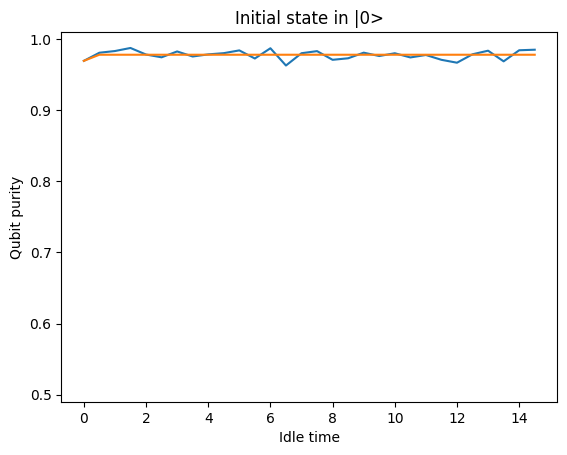

Fitted oscillation frequency: 0


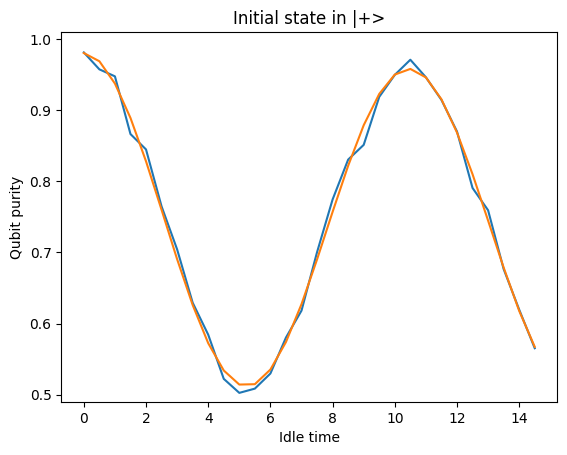

Fitted oscillation frequency: 0.29991423870205747


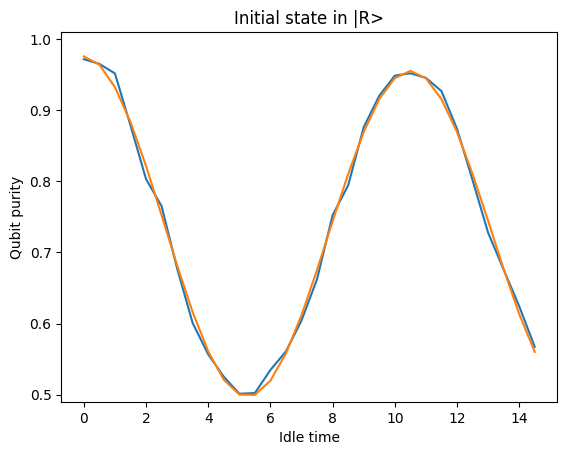

Fitted oscillation frequency: 0.29858729002731654
The amount of single-qubit non-Markovian noise induced purity oscillation is 0.29991423870205747


In [4]:
def fit_func(x, a, b, decay_rate, osc_freq):
    return a + b * np.e **(-1 * decay_rate * x) * np.cos(x * osc_freq) ** 2


idle_times = np.arange(0, t_max, dt)[:total_steps]
fit_freqs = []
for initial_state in [Z, X, Y]:
    popt, pcov = curve_fit(fit_func, idle_times, results[initial_state], p0=[0.5, 0.5, 0.5, 0.5])

    plt.plot(idle_times, results[initial_state])
    plt.plot(idle_times, fit_func(np.array(idle_times), *popt))
    plt.ylim(0.49, 1.01)
    plt.xlabel(f"Idle time")
    plt.ylabel(f"Qubit purity")
    plt.title(f"Initial state in |{'+' if initial_state == X else 'R' if initial_state == Y else 0}>")
    plt.show()

    # Discard if oscillation amplitude is too small
    fit_freq = np.absolute(popt[3])
    if np.absolute(popt[1]) < 0.01:
        fit_freq = 0
    fit_freqs.append(fit_freq)
    print(f"Fitted oscillation frequency: {fit_freq}")

print(f"The amount of single-qubit non-Markovian noise induced purity oscillation is {max(fit_freqs)}")


# Run on AWS hardware

In [5]:
import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))

# Disregard any warning on the following imports
from _helpers.circuit_submitter import CircuitSubmitter

In [19]:
device_name = "noisy_sim"

submitter = CircuitSubmitter("non-markovian_noise", device_name)
# Uncomment the following lines if you are using a noisy simulator and would like to change the noise model
# noise_model = None
# submitter.backend.device.noisy_sim.set_options(noise_model=noise_model)

tasks = submitter.submit_circuits(shots=shots, qasm_strs=[c.qasm() for c in circuits])
all_counts = submitter.retrieve_counts(wait=True)
results = []
purities = []
for i, counts in enumerate(all_counts):
    purity = 1
    prob_0 = 0
    if "00" in counts.keys():
        prob_0 += counts["00"] / shots
    if "01" in counts.keys():
        prob_0 += counts["01"] / shots
    purity += (2 * prob_0 - 1) ** 2 
    if (i+1) % 3 == 0:
        purity /= 2
        purities.append(purity)
        purity = 0
    if (i+1) % (total_steps * 3) == 0:
        results.append(purities)
        purities = []
print(results)
print(np.array(results).shape)

Ready to run 270 circuits on noisy_sim with 1000 shots.
Cost: 270 * ($0 + 1000 * $0) = $0.00.
Circuits have been submitted
2024-03-20 22:03:13 All circuits are finished
{'00': 500, '10': 0, '01': 500, '11': 0}
{'00': 250, '10': 250, '01': 250, '11': 250}
{'00': 250, '10': 250, '01': 250, '11': 250}
{'00': 500, '10': 0, '01': 500, '11': 0}
{'00': 250, '10': 250, '01': 250, '11': 250}
{'00': 250, '10': 250, '01': 250, '11': 250}
{'00': 500, '10': 0, '01': 500, '11': 0}
{'00': 250, '10': 250, '01': 250, '11': 250}
{'00': 250, '10': 250, '01': 250, '11': 250}
{'00': 500, '10': 0, '01': 500, '11': 0}
{'00': 250, '10': 250, '01': 250, '11': 250}
{'00': 250, '10': 250, '01': 250, '11': 250}
{'00': 500, '10': 0, '01': 500, '11': 0}
{'00': 250, '10': 250, '01': 250, '11': 250}
{'00': 250, '10': 250, '01': 250, '11': 250}
{'00': 500, '10': 0, '01': 500, '11': 0}
{'00': 250, '10': 250, '01': 250, '11': 250}
{'00': 250, '10': 250, '01': 250, '11': 250}
{'00': 500, '10': 0, '01': 500, '11': 0}
{'00

/home/wz2/.conda/envs/myenv/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


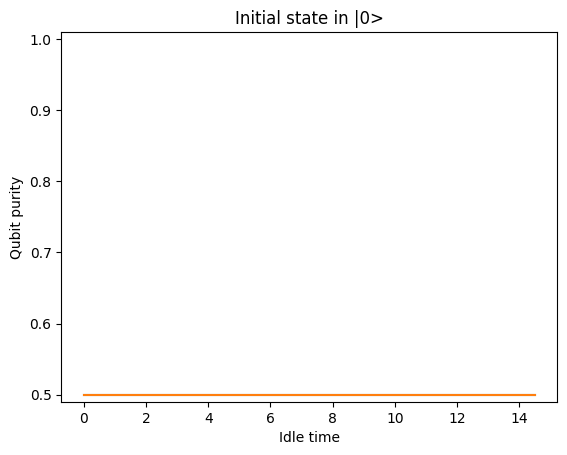

/home/wz2/.conda/envs/myenv/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Fitted oscillation frequency: 0


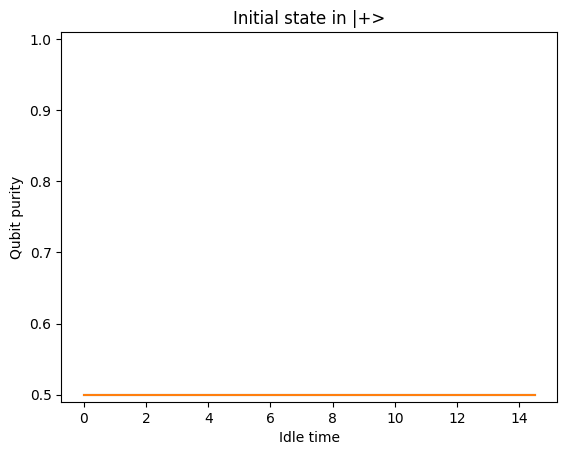

Fitted oscillation frequency: 0


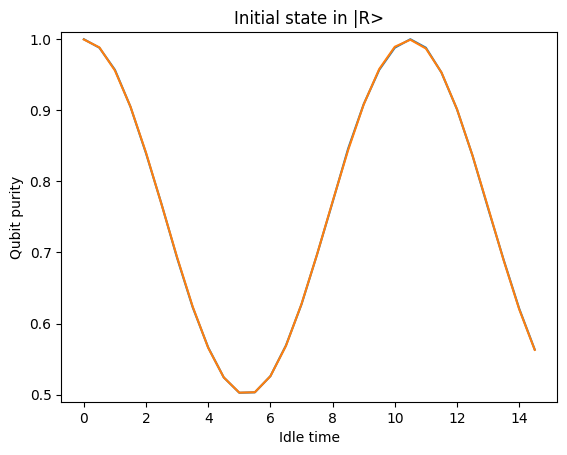

Fitted oscillation frequency: 0.2999926301907199
The amount of single-qubit non-Markovian noise induced purity oscillation is 0.2999926301907199


In [20]:
idle_times = np.arange(0, t_max, dt)[:total_steps]
fit_freqs = []
for initial_state in [Z, X, Y]:
    popt, pcov = curve_fit(fit_func, idle_times, results[initial_state], p0=[0.5, 0.5, 0.5, 0.5])

    plt.plot(idle_times, results[initial_state])
    plt.plot(idle_times, fit_func(np.array(idle_times), *popt))
    plt.ylim(0.49, 1.01)
    plt.xlabel(f"Idle time")
    plt.ylabel(f"Qubit purity")
    plt.title(f"Initial state in |{'+' if initial_state == X else 'R' if initial_state == Y else 0}>")
    plt.show()

    # Discard if oscillation amplitude is too small
    fit_freq = np.absolute(popt[3])
    if np.absolute(popt[1]) < 0.01:
        fit_freq = 0
    fit_freqs.append(fit_freq)
    print(f"Fitted oscillation frequency: {fit_freq}")

print(f"The amount of single-qubit non-Markovian noise induced purity oscillation is {max(fit_freqs)}")
